In [1]:
import sys
import nilearn

print("当前使用的 Python 路径:", sys.executable)
print("Nilearn 版本:", nilearn.__version__)

当前使用的 Python 路径: C:\Users\28439\miniconda3\envs\mri_env\python.exe
Nilearn 版本: 0.13.1


In [3]:
import os
from nilearn import datasets

data_dir = os.path.join(os.getcwd(), "abide_data")
print(f"数据将下载到: {data_dir}")

# pipeline='cpac': 使用广泛的 CPAC 预处理流水线
# derivatives='rois_aal': 提取 AAL 脑分区模板下的时间序列特征（文件小，最适合做 AI 分类）
abide_data = datasets.fetch_abide_pcp(
    data_dir=data_dir,
    pipeline="cpac",
    derivatives="rois_aal",
    quality_checked=True  # 自动剔除伪影严重、质量不合格的样本
)


print(f"成功获取了 {len(abide_data.phenotypic)} 个受试者的数据。")

数据将下载到: C:\Users\28439\Desktop\ASD\abide_data
[fetch_abide_pcp] Dataset found in C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp
成功获取了 871 个受试者的数据。


In [2]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp\Phenotypic_V1_0b_preprocessed1.csv")
data.head(7)

,Unnamed: 0.1,Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,...,qc_notes_rater_1,qc_anat_rater_2,qc_anat_notes_rater_2,qc_func_rater_2,qc_func_notes_rater_2,qc_anat_rater_3,qc_anat_notes_rater_3,qc_func_rater_3,qc_func_notes_rater_3,SUB_IN_SMP
0,0,1,50002,1,50002,PITT,no_filename,1,1,16.77,...,NaN,OK,NaN,fail,ic-parietal-cerebellum,OK,NaN,fail,ERROR #24,1
1,1,2,50003,2,50003,PITT,Pitt_0050003,1,1,24.45,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
2,2,3,50004,3,50004,PITT,Pitt_0050004,1,1,19.09,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
3,3,4,50005,4,50005,PITT,Pitt_0050005,1,1,13.73,...,NaN,OK,NaN,maybe,ic-parietal-cerebellum,OK,NaN,OK,NaN,0
4,4,5,50006,5,50006,PITT,Pitt_0050006,1,1,13.37,...,NaN,OK,NaN,maybe,ic-parietal slight,OK,NaN,OK,NaN,1
5,5,6,50007,6,50007,PITT,Pitt_0050007,1,1,17.78,...,NaN,OK,NaN,maybe,ic-cerebellum_temporal_lob,OK,NaN,OK,NaN,1
6,6,7,50008,7,50008,PITT,Pitt_0050008,1,1,32.45,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1


In [3]:
# 检查 ADOS 和 ADI_R 量表数剧，有ADOS，ADI这些就能确保是ASD的表格了
diagnostic_cols = ['ADOS_TOTAL', 'ADI_R_SOCIAL_TOTAL_A', 'SCQ_TOTAL']
print(data[diagnostic_cols].describe())

        ADOS_TOTAL  ADI_R_SOCIAL_TOTAL_A    SCQ_TOTAL
count   442.000000            412.000000   143.000000
mean   -600.411765           -807.024272 -1318.482517
std    2400.010037           2760.138808  3409.862857
min   -9999.000000          -9999.000000 -9999.000000
25%       8.000000             14.000000     1.000000
50%      11.000000             20.000000     8.000000
75%      14.000000             24.000000    17.500000
max      22.000000             30.000000    37.000000


### 处理一下数据，看看概况

In [4]:
data.describe()

,Unnamed: 0.1,Unnamed: 0,SUB_ID,X,subject,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,SEX,HANDEDNESS_SCORES,...,func_fber,func_fwhm,func_dvars,func_outlier,func_quality,func_mean_fd,func_num_fd,func_perc_fd,func_gsr,SUB_IN_SMP
count,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000,370.000000,...,1099.000000,1099.000000,1099.000000,1099.000000,1099.000000,1099.000000,1099.000000,1099.000000,1099.000000,1112.000000
mean,555.500000,556.500000,50752.684353,556.500000,50752.684353,1.515288,-646.819245,17.048864,1.147482,-102.560892,...,100.548498,2.116388,1.103531,0.005525,0.012778,0.131138,27.218380,12.952826,0.028416,0.686151
std,321.151055,321.151055,447.680666,321.151055,447.680666,0.499991,2461.828856,8.036419,0.354745,1273.177790,...,43.552970,0.345282,0.117803,0.006464,0.011212,0.157728,42.757583,18.216671,0.021070,0.464265
min,0.000000,1.000000,50002.000000,1.000000,50002.000000,1.000000,-9999.000000,6.470000,1.000000,-9999.000000,...,33.836513,1.581108,0.709671,0.000182,0.001693,0.016117,0.000000,0.000000,-0.015812,0.000000
25%,277.750000,278.750000,50354.750000,278.750000,50354.750000,1.000000,0.000000,11.658575,1.000000,48.000000,...,69.047209,1.862772,1.026977,0.001124,0.006333,0.050888,2.000000,0.995025,0.013075,0.000000
50%,555.500000,556.500000,50724.500000,556.500000,50724.500000,2.000000,0.000000,14.660000,1.000000,75.000000,...,87.681334,2.004123,1.080727,0.003441,0.010043,0.083163,9.000000,4.972376,0.031102,1.000000
75%,833.250000,834.250000,51153.250000,834.250000,51153.250000,2.000000,1.000000,20.085000,1.000000,91.000000,...,125.779269,2.328370,1.172068,0.006977,0.015189,0.143479,33.000000,16.977985,0.042821,1.000000
max,1111.000000,1112.000000,51607.000000,1112.000000,51607.000000,2.000000,4.000000,64.000000,2.000000,100.000000,...,326.544102,3.753481,1.571101,0.080158,0.098614,1.434912,288.000000,91.735537,0.104225,1.000000


In [5]:
data_pivot = data[["SUB_ID","DX_GROUP","AGE_AT_SCAN","SEX","ADI_R_SOCIAL_TOTAL_A","ADOS_TOTAL"]]
data_pivot

,SUB_ID,DX_GROUP,AGE_AT_SCAN,SEX,ADI_R_SOCIAL_TOTAL_A,ADOS_TOTAL
0,50002,1,16.77,1,16.0,12.0
1,50003,1,24.45,1,27.0,13.0
2,50004,1,19.09,1,19.0,18.0
3,50005,1,13.73,2,23.0,12.0
4,50006,1,13.37,1,13.0,12.0
...,...,...,...,...,...,...
1107,51583,1,35.00,1,-9999.0,-9999.0
1108,51584,1,49.00,1,9.0,12.0
1109,51585,1,27.00,1,-9999.0,-9999.0
1110,51606,1,29.00,2,NaN,NaN


In [8]:
data_example = pd.read_csv(r"C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp\cpac\nofilt_noglobal\Caltech_0051461_rois_aal.1D", sep='\t', header=None)
print(data_example.shape)
# (196, 116)，代表 196 个时间点，116 个脑区

(147, 116)


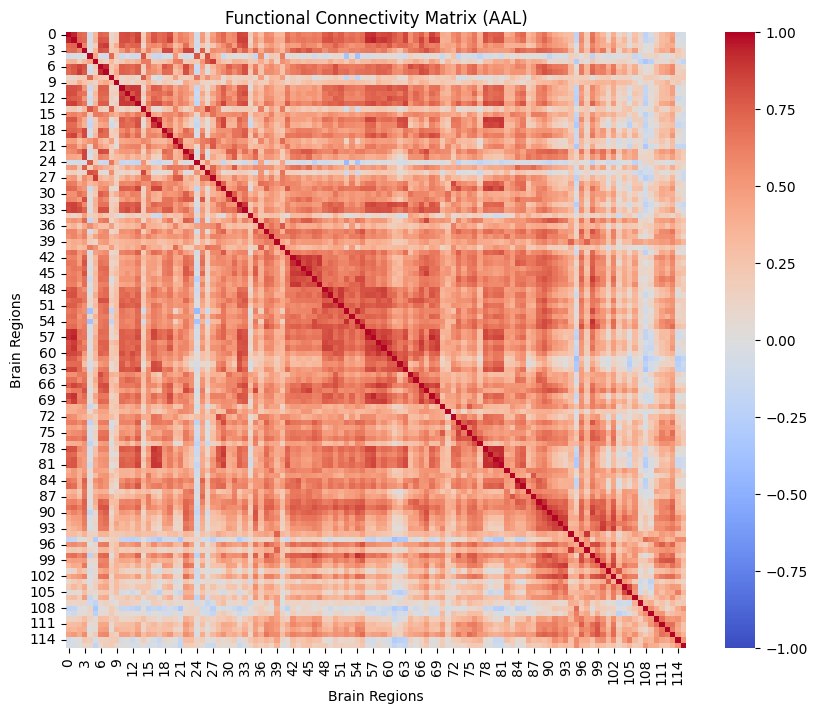

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp\cpac\nofilt_noglobal\Caltech_0051461_rois_aal.1D"
data_example = np.loadtxt(file_path)

# 2. 计算相关矩阵 (Correlation Matrix)
# 我们关心的是 116 个脑区之间的关系，所以是对列做相关
corr_matrix = np.corrcoef(data_example, rowvar=False)

# 3. 可视化相关性热力图 (这在脑科学里叫功能连接矩阵)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Functional Connectivity Matrix (AAL)")
plt.xlabel("Brain Regions")
plt.ylabel("Brain Regions")
plt.show()

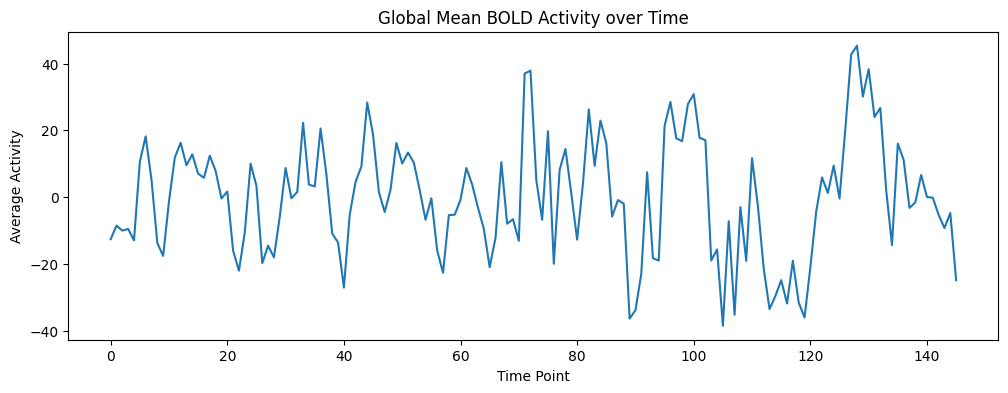

In [10]:
# 1. 查看平均波动 (每个时间点所有脑区的平均值)
mean_activity = data_example.mean(axis=1)

# 2. 绘制时间序列图
plt.figure(figsize=(12, 4))
plt.plot(mean_activity)
plt.title("Global Mean BOLD Activity over Time")
plt.xlabel("Time Point")
plt.ylabel("Average Activity")
plt.show()